<a href="https://colab.research.google.com/github/shreyanariya15/AI-ML-TRAIINING-/blob/main/Data_Cleaning_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Cleaning Steps
1. importing datasets
2. Merge datasets into one dataset
3. identify errors
4. standardize processes
5. scrub for duplicates
6. validate accuracy

# Import the daata set

# Merge datasets into one dataset
### What is merge Function
> merge connect columns or indexes in DataFrame based on one or more keys.

In [ ]:
import pandas as pd

In [ ]:
df_1 = pd.DataFrame({'ID' : [1,2,3,5],
                     'Class' : [9,10,2,11]})
df_1

,ID,Class
0,1,9
1,2,10
2,3,2
3,5,11


In [ ]:
# pd.merge()

In [ ]:
df_2 = pd.DataFrame({ 'ID' : [1,2,3,4],
                    'Name' : ['A',"B",'C','d']})
df_2

,ID,Name
0,1,A
1,2,B
2,3,C
3,4,d


In [ ]:
merge_df = pd.merge(df_1, df_2, on = 'ID')
merge_df

,ID,Class,Name
0,1,9,A
1,2,10,B
2,3,2,C


In [ ]:
merge_df_in = pd.merge(df_1, df_2, on = 'ID', how = 'inner')
merge_df_in

,ID,Class,Name
0,1,9,A
1,2,10,B
2,3,2,C


In [ ]:
merge_df_left = pd.merge(df_1, df_2, on = 'ID', how = 'left')
merge_df_left

,ID,Class,Name
0,1,9,A
1,2,10,B
2,3,2,C
3,5,11,NaN


In [ ]:
merge_df_right = pd.merge(df_1, df_2, on = 'ID', how = 'right')
merge_df_right

,ID,Class,Name
0,1,9.0,A
1,2,10.0,B
2,3,2.0,C
3,4,NaN,d


In [ ]:
merge_df_outer = pd.merge(df_1, df_2, on = 'ID', how = 'outer')
merge_df_outer

,ID,Class,Name
0,1,9.0,A
1,2,10.0,B
2,3,2.0,C
3,4,NaN,d
4,5,11.0,NaN


In [ ]:
merge_df_indicator = pd.merge(df_1, df_2, on = 'ID', how = 'outer', indicator = True)
merge_df_indicator

,ID,Class,Name,_merge
0,1,9.0,A,both
1,2,10.0,B,both
2,3,2.0,C,both
3,4,NaN,d,right_only
4,5,11.0,NaN,left_only


In [ ]:
# if we have multiindex
pd.merge(df_1 , df_2, left_index = True, right_index = True)

,ID_x,Class,ID_y,Name
0,1,9,1,A
1,2,10,2,B
2,3,2,3,C
3,5,11,4,d


In [ ]:
df1 = pd.DataFrame({
    'User_ID': [101, 102, 103],
    'Name': ['Alice', 'Bob', 'Charlie']
}, index = [11,22,33])

print(df1)

df2 = pd.DataFrame({
    'User_ID': [101, 102, 104],
    'City': ['New York', 'London', 'Paris']
}, index = [100,200,300])

print(df2)


# merged_df = pd.merge(df1, df2, on='User_ID', how='inner')
# merged_df


index_access  = pd.merge(df1,df2, left_index = True, right_index = True)
index_access




    User_ID     Name
11      101    Alice
22      102      Bob
33      103  Charlie
     User_ID      City
100      101  New York
200      102    London
300      104     Paris


,User_ID_x,Name,User_ID_y,City


In [ ]:
df_21 = pd.DataFrame({
    'User_ID': [101, 102, 103],
    'Name': ['Alice', 'Bob', 'Charlie']
}, index = [11,22,33])

print(df_21)

df_22 = pd.DataFrame({
    'User_ID': [101, 102, 104],
    'City': ['New York', 'London', 'Paris']
}, index = [11,22,33])

print(df_22)

indx = pd.merge(df_21,df_22, left_index = True, right_index = True)
indx

    User_ID     Name
11      101    Alice
22      102      Bob
33      103  Charlie
    User_ID      City
11      101  New York
22      102    London
33      104     Paris


,User_ID_x,Name,User_ID_y,City
11,101,Alice,101,New York
22,102,Bob,102,London
33,103,Charlie,104,Paris


# Handling Missing Values

In [ ]:
import numpy as np

In [ ]:
# simple nan values data set
data = {
    'Age': [25, np.nan, 30, 22, np.nan],
    'Score': [85, 90, np.nan, 75, 80],
    'City': ['New York', 'Paris', 'London', np.nan, 'Paris']
}
dataf = pd.DataFrame(data)
print("Original DataFrame:\n", dataf)


Original DataFrame:
     Age  Score      City
0  25.0   85.0  New York
1   NaN   90.0     Paris
2  30.0    NaN    London
3  22.0   75.0       NaN
4   NaN   80.0     Paris


### 1. Detect Missing Values

In [ ]:
# Check for nulls (returns True/False)
print(dataf.isnull())

# Count missing values per column
print(dataf.isnull().sum())


     Age  Score   City
0  False  False  False
1   True  False  False
2  False   True  False
3  False  False   True
4   True  False  False
Age      2
Score    1
City     1
dtype: int64


In [ ]:
dataf.notnull()

,Age,Score,City
0,True,True,True
1,False,True,True
2,True,False,True
3,True,True,False
4,False,True,True


### 2. Delete Missing Data

In [ ]:
# Remove any rows containing at least one missing value
df_clean_rows = dataf.dropna()

# Remove columns containing at least one missing value
df_clean_cols = dataf.dropna(axis=1)

# Drop rows only if missing values are in a specific column
df_clean_subset = dataf.dropna(subset=['Age'])


In [ ]:
df_clean_rows

,Age,Score,City
0,25.0,85.0,New York


In [ ]:
df_clean_cols

""
0
1
2
3
4


In [ ]:
df_clean_subset

,Age,Score,City
0,25.0,85.0,New York
2,30.0,NaN,London
3,22.0,75.0,NaN


### 3. Impute (Fill) Missing Data

In [ ]:
# Fill all missing values with a fixed constant (e.g., 0)
df_zero = dataf.fillna(0)

# Fill numerical missing values with the column mean
dataf['Age'] = dataf['Age'].fillna(dataf['Age'].mean())

# Fill categorical missing values with the column mode (most frequent)
dataf['City'] = dataf['City'].fillna(dataf['City'].mode()[0])


In [ ]:
df_zero

,Age,Score,City
0,25.0,85.0,New York
1,0.0,90.0,Paris
2,30.0,0.0,London
3,22.0,75.0,0
4,0.0,80.0,Paris


In [ ]:
dataf['Age']

0    25.000000
1    25.666667
2    30.000000
3    22.000000
4    25.666667
Name: Age, dtype: float64

In [ ]:
dataf['City']

0    New York
1       Paris
2      London
3       Paris
4       Paris
Name: City, dtype: object

### 4. Time-Series Interpolation

In [ ]:
# Forward fill: carry the previous valid value forward
df_ffill = dataf.ffill()

# Backward fill: carry the next valid value backward
df_bfill = dataf.bfill()

# Linear interpolation: estimate intermediate values
df_interp = dataf.select_dtypes(include=[np.number]).interpolate()


In [ ]:
df_ffill

,Age,Score,City
0,25.000000,85.0,New York
1,25.666667,90.0,Paris
2,30.000000,90.0,London
3,22.000000,75.0,Paris
4,25.666667,80.0,Paris


In [ ]:
df_bfill

,Age,Score,City
0,25.000000,85.0,New York
1,25.666667,90.0,Paris
2,30.000000,75.0,London
3,22.000000,75.0,Paris
4,25.666667,80.0,Paris


In [ ]:
df_interp

,Age,Score
0,25.000000,85.0
1,25.666667,90.0
2,30.000000,82.5
3,22.000000,75.0
4,25.666667,80.0


### 5. Advanced Machine Learning Imputation

In [ ]:
from sklearn.impute import SimpleImputer, KNNImputer

# Strategy choices: 'mean', 'median', 'most_frequent', 'constant'
mean_imputer = SimpleImputer(strategy='mean')
dataf[['Age', 'Score']] = mean_imputer.fit_transform(dataf[['Age', 'Score']])

# K-Nearest Neighbors imputation based on similar samples
knn_imputer = KNNImputer(n_neighbors=2)
dataf_knn = knn_imputer.fit_transform(dataf[['Age', 'Score']])


In [ ]:
dataf[['Age', 'Score']]

,Age,Score
0,25.000000,85.0
1,25.666667,90.0
2,30.000000,82.5
3,22.000000,75.0
4,25.666667,80.0


In [ ]:
dataf_knn

array([[25.        , 85.        ],
       [25.66666667, 90.        ],
       [30.        , 82.5       ],
       [22.        , 75.        ],
       [25.66666667, 80.        ]])

## Removing Duplicates: |

In [ ]:
# 1. Create a sample DataFrame with duplicate rows
data = {
    'Name': ['Alice', 'Bob', 'Alice', 'Alice', 'Charlie'],
    'Age': [25, 30, 25, 26, 35],
    'City': ['New York', 'Paris', 'New York', 'London', 'Berlin']
}
dfr = pd.DataFrame(data)
print("Original DataFrame:")
print(dfr)
print("\n" + "="*40 + "\n")



Original DataFrame:
      Name  Age      City
0    Alice   25  New York
1      Bob   30     Paris
2    Alice   25  New York
3    Alice   26    London
4  Charlie   35    Berlin




In [ ]:
# 2. Remove exact duplicate rows (keeps the first occurrence by default)
dfr_no_duplicates = dfr.drop_duplicates()
print("1. After removing exact duplicates (keeps first):")
print(dfr_no_duplicates)
print("\n" + "="*40 + "\n")


1. After removing exact duplicates (keeps first):
      Name  Age      City
0    Alice   25  New York
1      Bob   30     Paris
3    Alice   26    London
4  Charlie   35    Berlin




In [ ]:
# 3. Remove duplicates based on a specific column
dfr_unique_names = dfr.drop_duplicates(subset=['Name'])
print("2. After removing duplicates based on 'Name' column only:")
print(dfr_unique_names)
print("\n" + "="*40 + "\n")

2. After removing duplicates based on 'Name' column only:
      Name  Age      City
0    Alice   25  New York
1      Bob   30     Paris
4  Charlie   35    Berlin




In [ ]:
# 4. Remove duplicates and keep the LAST occurrence
df_keep_last = dfr.drop_duplicates(subset=['Name'], keep='last')
print("3. Keeping the LAST occurrence of duplicate names:")
print(df_keep_last)
print("\n" + "="*40 + "\n")



3. Keeping the LAST occurrence of duplicate names:
      Name  Age    City
1      Bob   30   Paris
3    Alice   26  London
4  Charlie   35  Berlin




In [ ]:
# 5. Drop ALL occurrences of duplicates completely
dfr_drop_all = dfr.drop_duplicates(subset=['Name'], keep=False)
print("4. Drop ALL rows that have duplicate names (keep=False):")
print(dfr_drop_all)
print("\n" + "="*40 + "\n")



4. Drop ALL rows that have duplicate names (keep=False):
      Name  Age    City
1      Bob   30   Paris
4  Charlie   35  Berlin




In [ ]:
# 6. Modify the original DataFrame in-place and reset the index
dfr.drop_duplicates(inplace=True, ignore_index=True)
print("5. Original DataFrame modified in-place with a reset index:")
print(dfr)

5. Original DataFrame modified in-place with a reset index:
      Name  Age      City
0    Alice   25  New York
1      Bob   30     Paris
2    Alice   26    London
3  Charlie   35    Berlin


# Data Cleaning on dataset

In [ ]:
'''

https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data

'''

' \n\nhttps://www.kaggle.com/c/house-prices-advanced-regression-techniques/data\n\n'

In [ ]:
h_df = pd.read_csv(r"E:\Data set\Data preprocessing\train.csv")
h_df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [ ]:
h_df.shape

(1460, 81)

In [ ]:
h_df.head(6)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000


### pd.set_option()

In [ ]:
pd.set_option('display.max_columns', None)



In [ ]:
h_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
h_df.tail(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,NaN,Attchd,1950.0,Unf,1,240,TA,TA,Y,366,0,112,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,6,1965,1965,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,CBlock,TA,TA,No,BLQ,830,LwQ,290,136,1256,GasA,Gd,Y,SBrkr,1256,0,0,1256,1,0,1,1,3,1,TA,6,Typ,0,NaN,Attchd,1965.0,Fin,1,276,TA,TA,Y,736,68,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [ ]:
h_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
h_df.isnull()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,False,False,False,False,False,False
1,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,False,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,False,False,False,False,False,False
3,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,False,False,False,False,False,False
4,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,

In [ ]:
h_df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

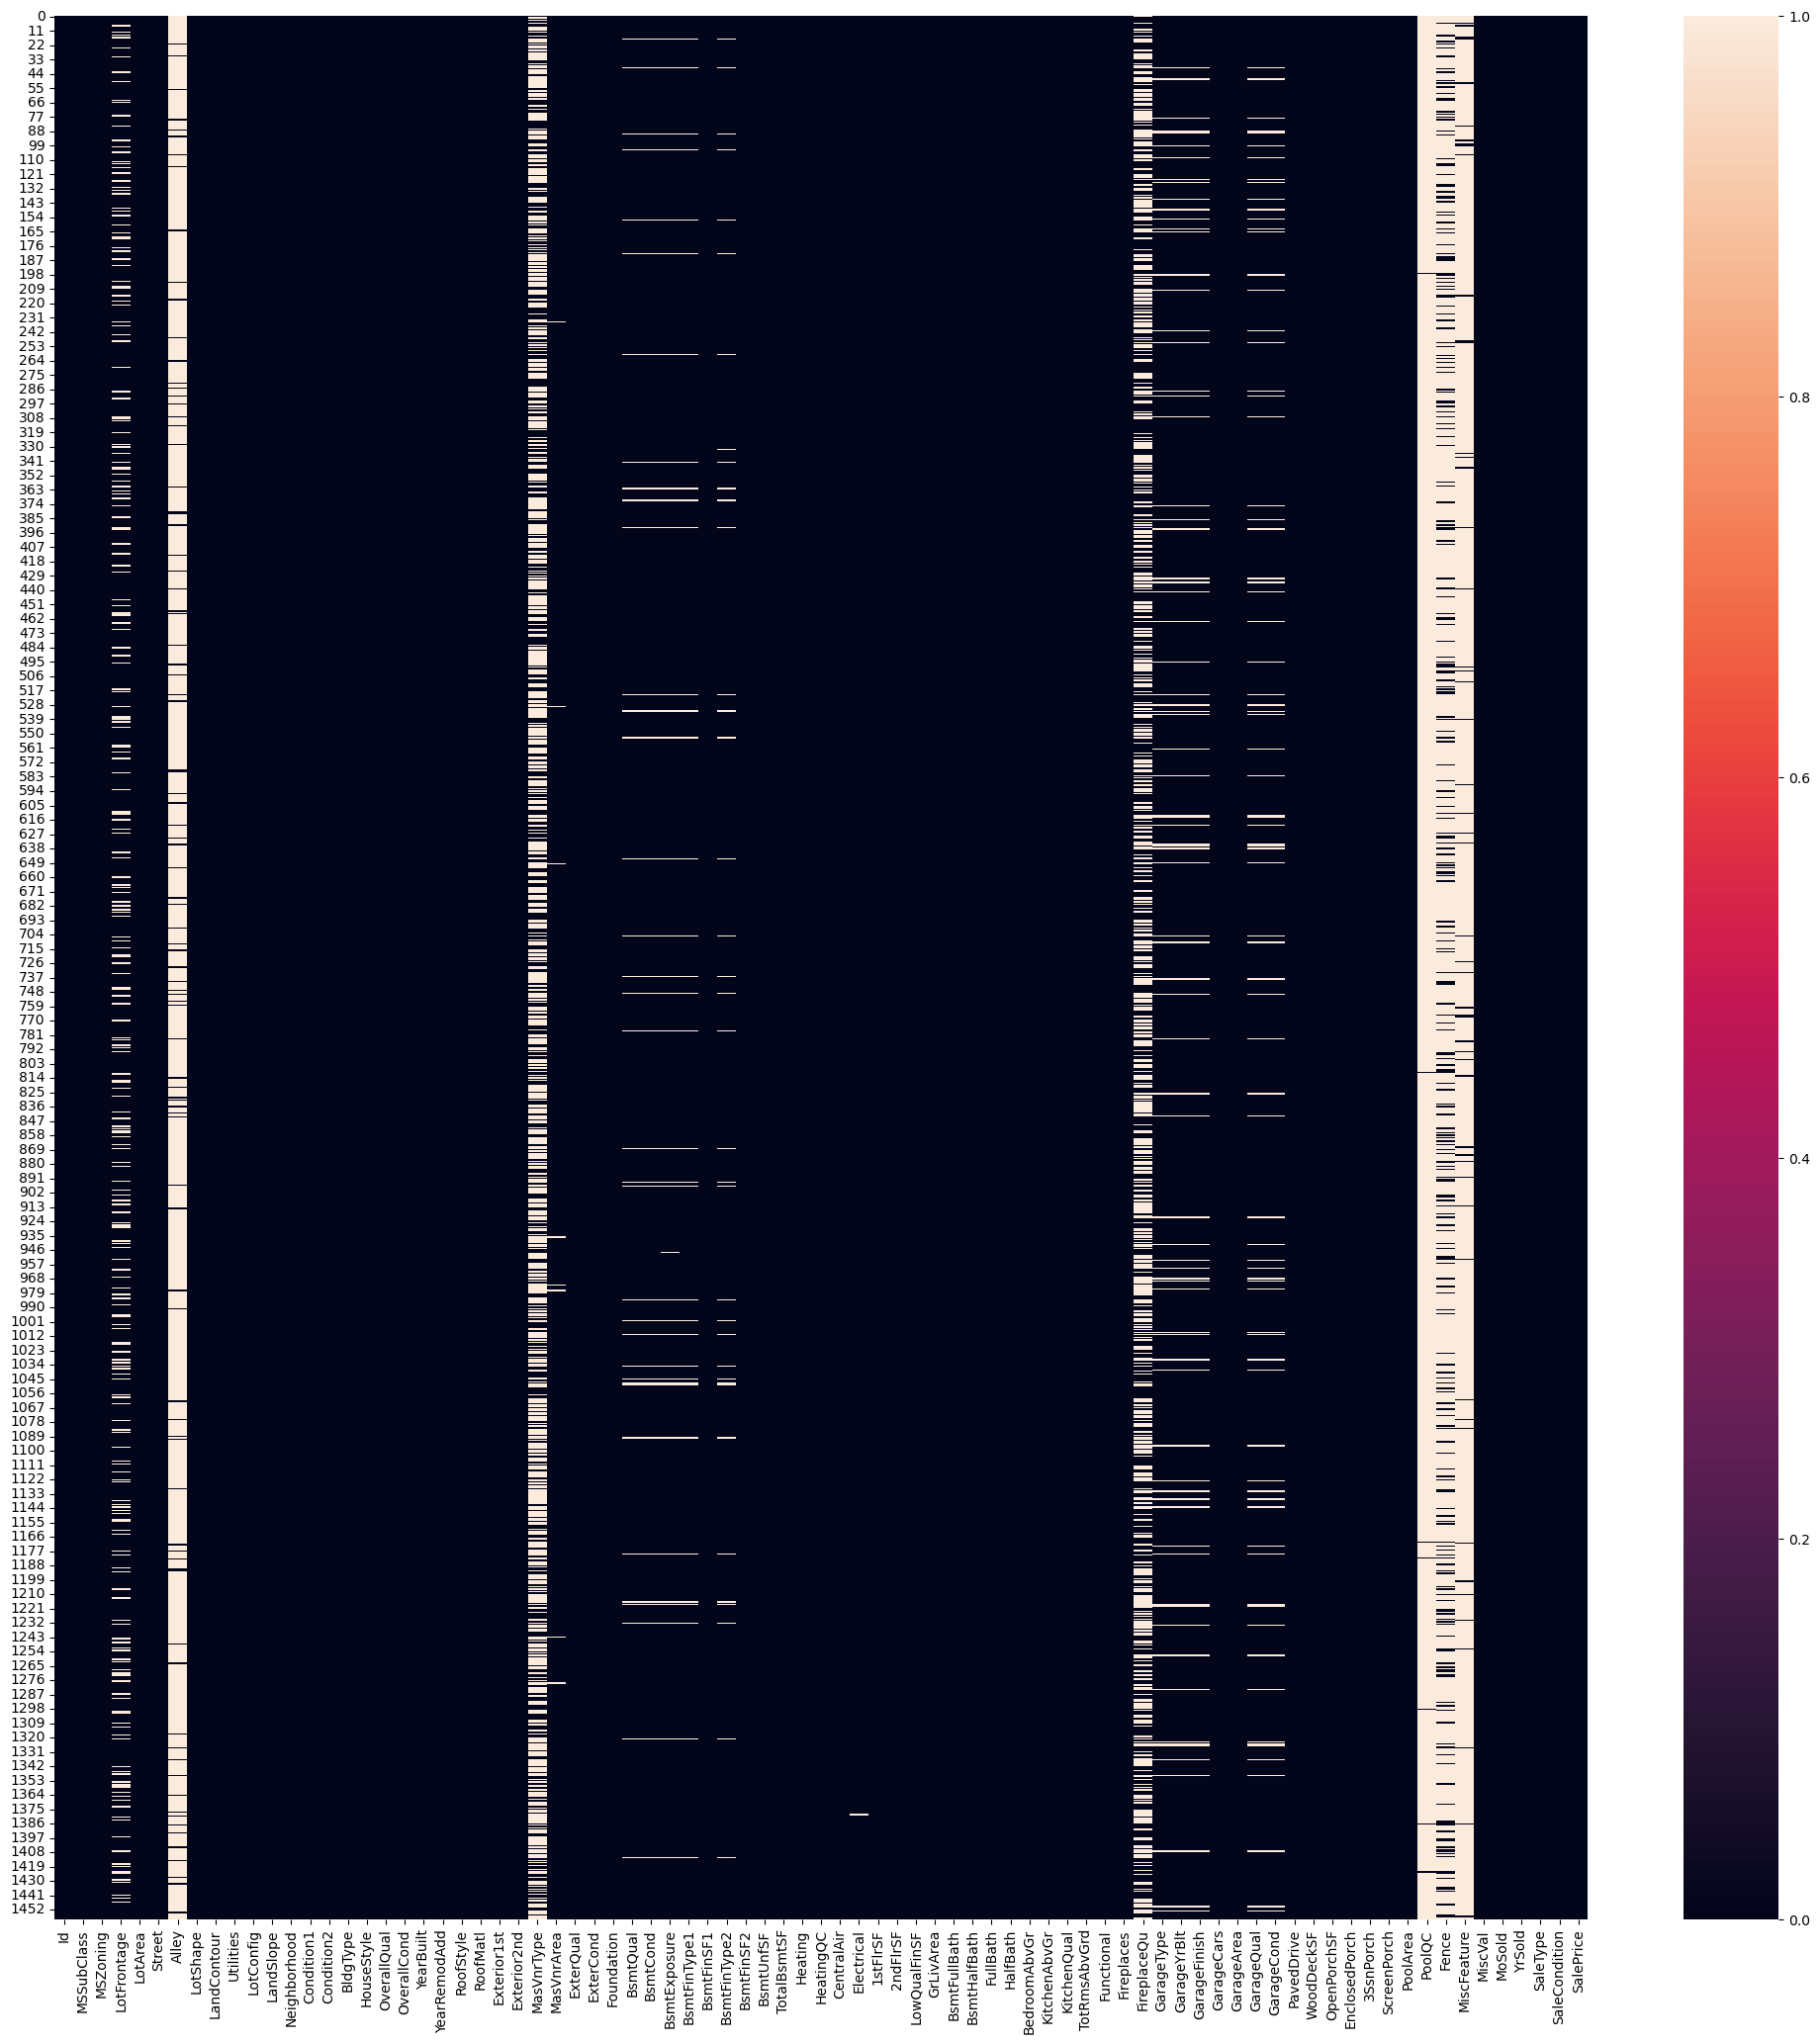

In [ ]:
plt.figure(figsize = (25,25))
sns.heatmap(h_df.isnull())

<Axes: >

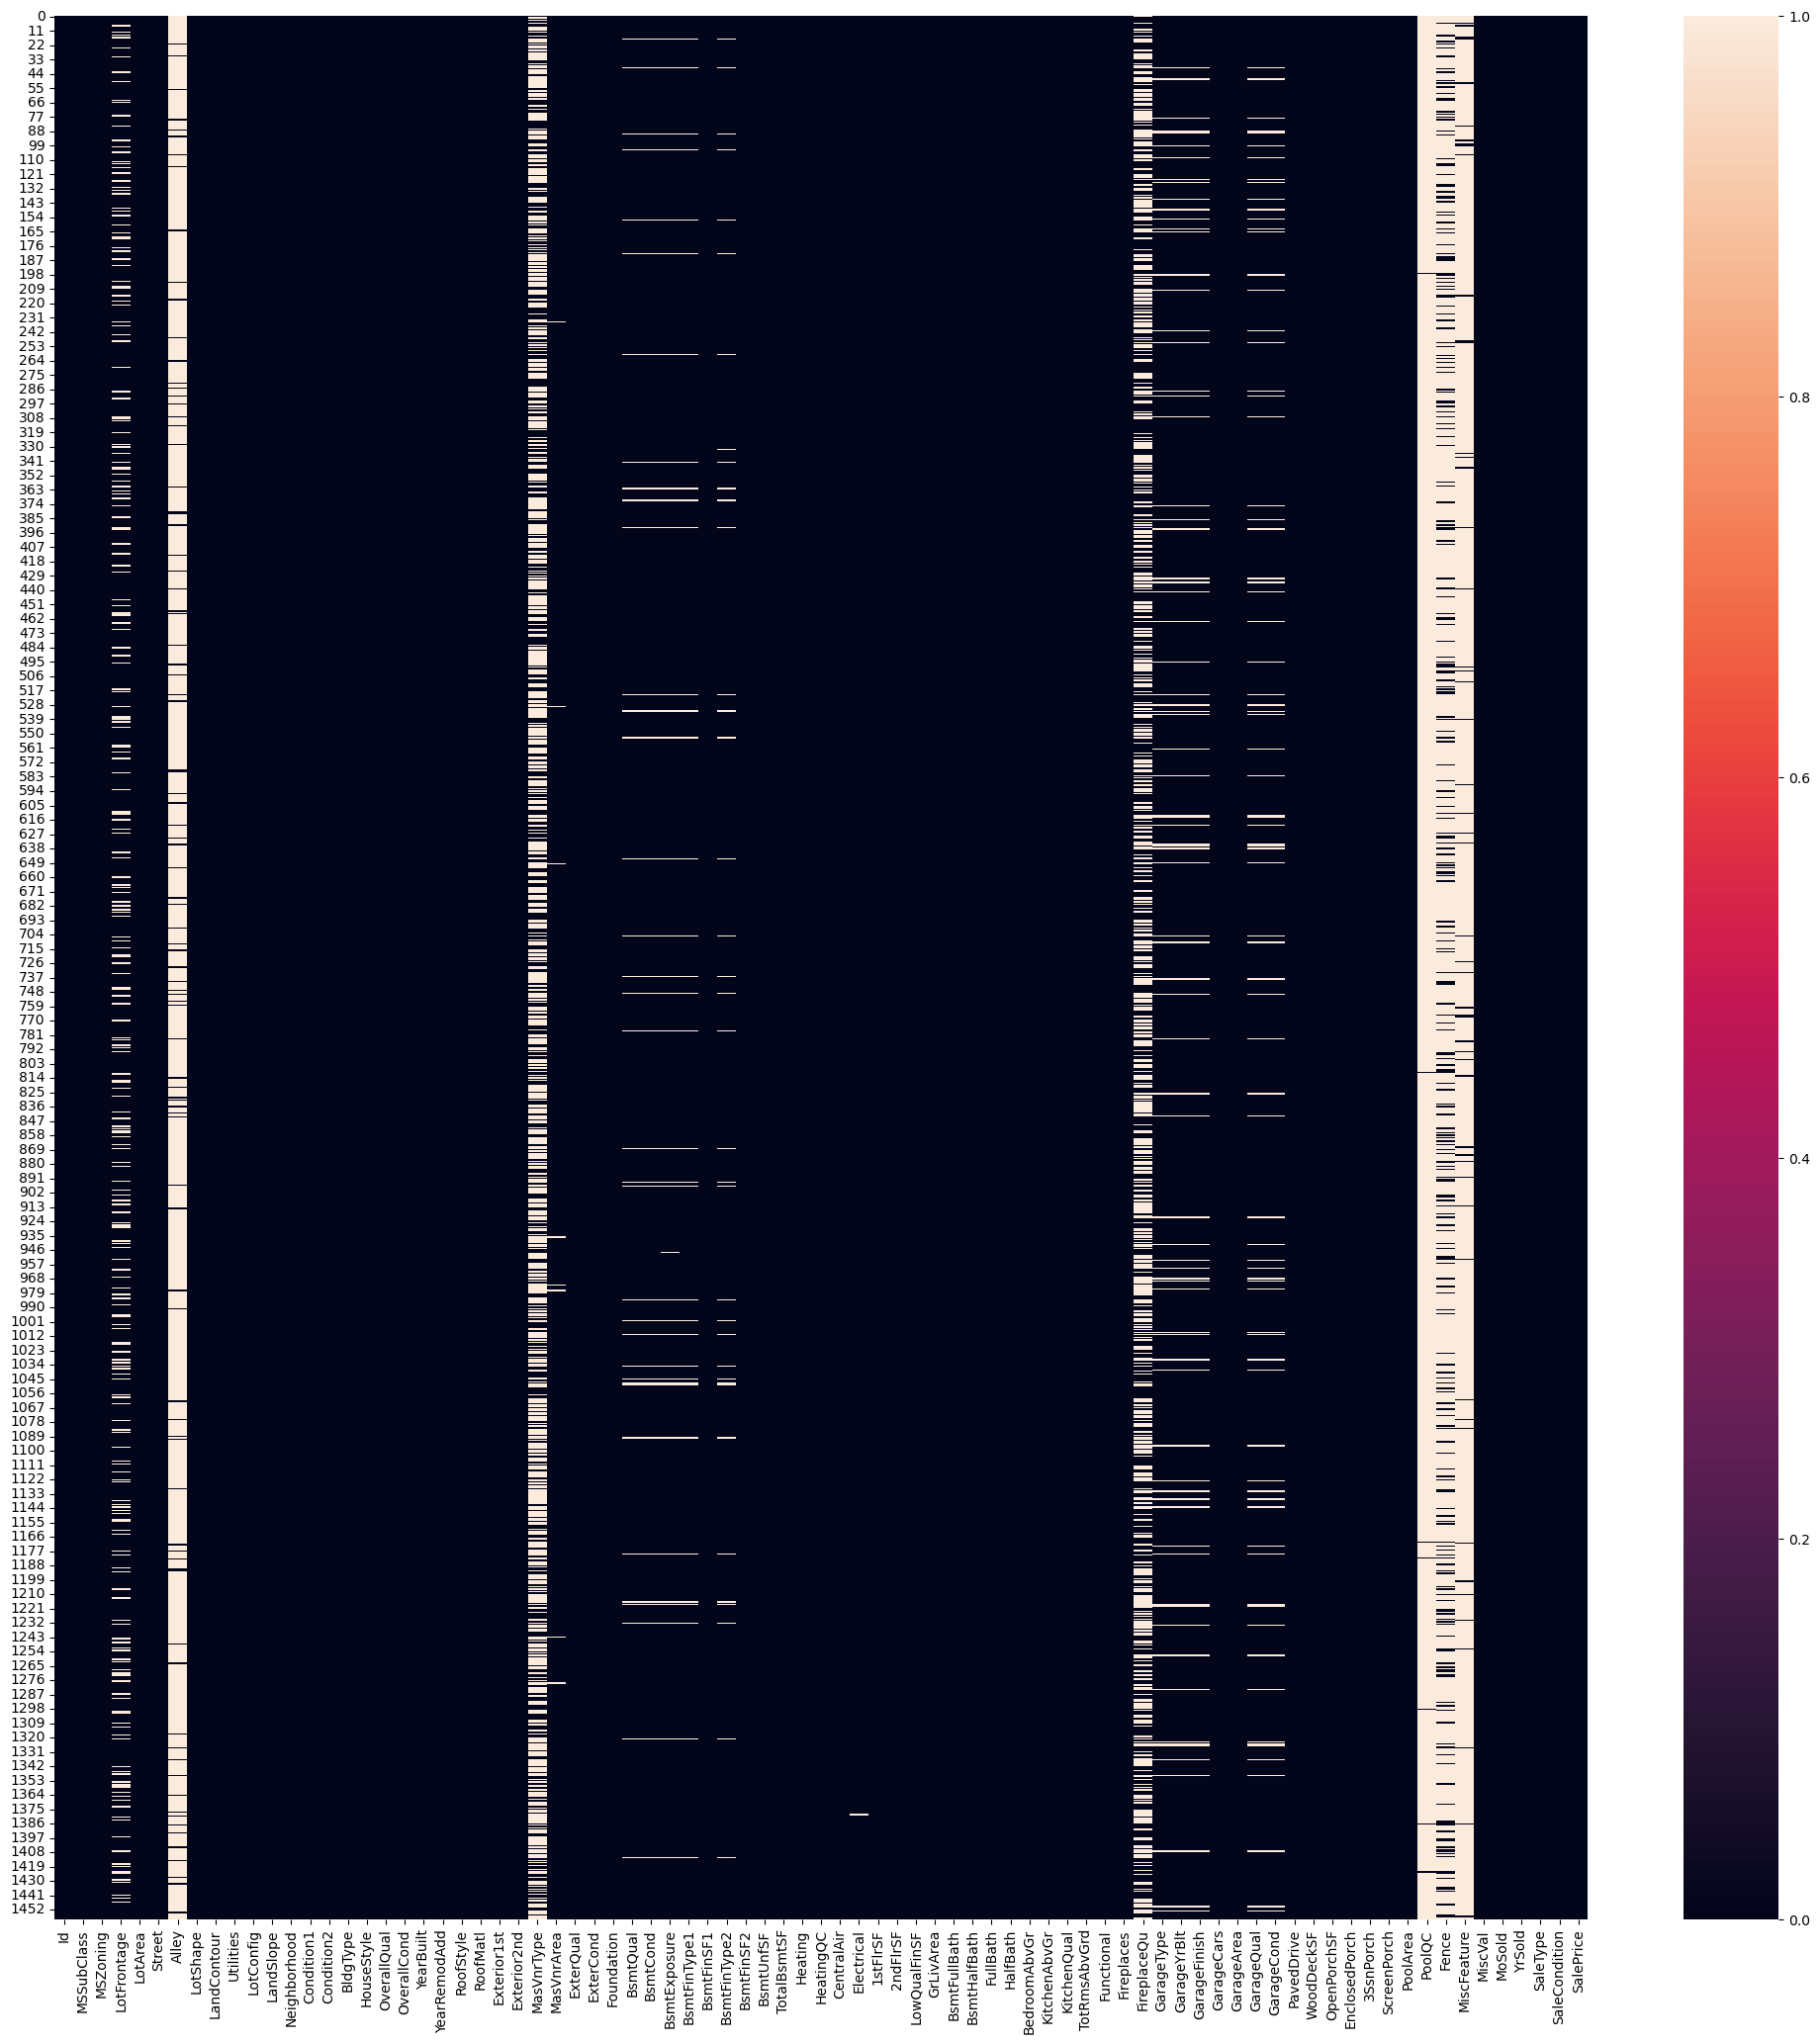

In [ ]:
plt.figure(figsize = (25,25))
sns.heatmap(h_df.isnull())

In [ ]:
pd.set_option('display.max_rows', None)

In [ ]:
h_df.isnull().sum()/h_df.shape[0] * 100

Id                0.000000
MSSubClass        0.000000
MSZoning          0.000000
LotFrontage      17.739726
LotArea           0.000000
Street            0.000000
Alley            93.767123
LotShape          0.000000
LandContour       0.000000
Utilities         0.000000
LotConfig         0.000000
LandSlope         0.000000
Neighborhood      0.000000
Condition1        0.000000
Condition2        0.000000
BldgType          0.000000
HouseStyle        0.000000
OverallQual       0.000000
OverallCond       0.000000
YearBuilt         0.000000
YearRemodAdd      0.000000
RoofStyle         0.000000
RoofMatl          0.000000
Exterior1st       0.000000
Exterior2nd       0.000000
MasVnrType       59.726027
MasVnrArea        0.547945
ExterQual         0.000000
ExterCond         0.000000
Foundation        0.000000
BsmtQual          2.534247
BsmtCond          2.534247
BsmtExposure      2.602740
BsmtFinType1      2.534247
BsmtFinSF1        0.000000
BsmtFinType2      2.602740
BsmtFinSF2        0.000000
B

In [ ]:
null_var = h_df.isnull().sum()/h_df.shape[0] * 100
null_var

Id                0.000000
MSSubClass        0.000000
MSZoning          0.000000
LotFrontage      17.739726
LotArea           0.000000
Street            0.000000
Alley            93.767123
LotShape          0.000000
LandContour       0.000000
Utilities         0.000000
LotConfig         0.000000
LandSlope         0.000000
Neighborhood      0.000000
Condition1        0.000000
Condition2        0.000000
BldgType          0.000000
HouseStyle        0.000000
OverallQual       0.000000
OverallCond       0.000000
YearBuilt         0.000000
YearRemodAdd      0.000000
RoofStyle         0.000000
RoofMatl          0.000000
Exterior1st       0.000000
Exterior2nd       0.000000
MasVnrType       59.726027
MasVnrArea        0.547945
ExterQual         0.000000
ExterCond         0.000000
Foundation        0.000000
BsmtQual          2.534247
BsmtCond          2.534247
BsmtExposure      2.602740
BsmtFinType1      2.534247
BsmtFinSF1        0.000000
BsmtFinType2      2.602740
BsmtFinSF2        0.000000
B

In [ ]:
drop_columns = null_var[null_var > 17].keys()
drop_columns

Index(['LotFrontage', 'Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence',
       'MiscFeature'],
      dtype='object')

In [ ]:
df2_drop_clm = h_df.drop(columns = drop_columns)


In [ ]:
df2_drop_clm.shape

(1460, 74)

<Axes: >

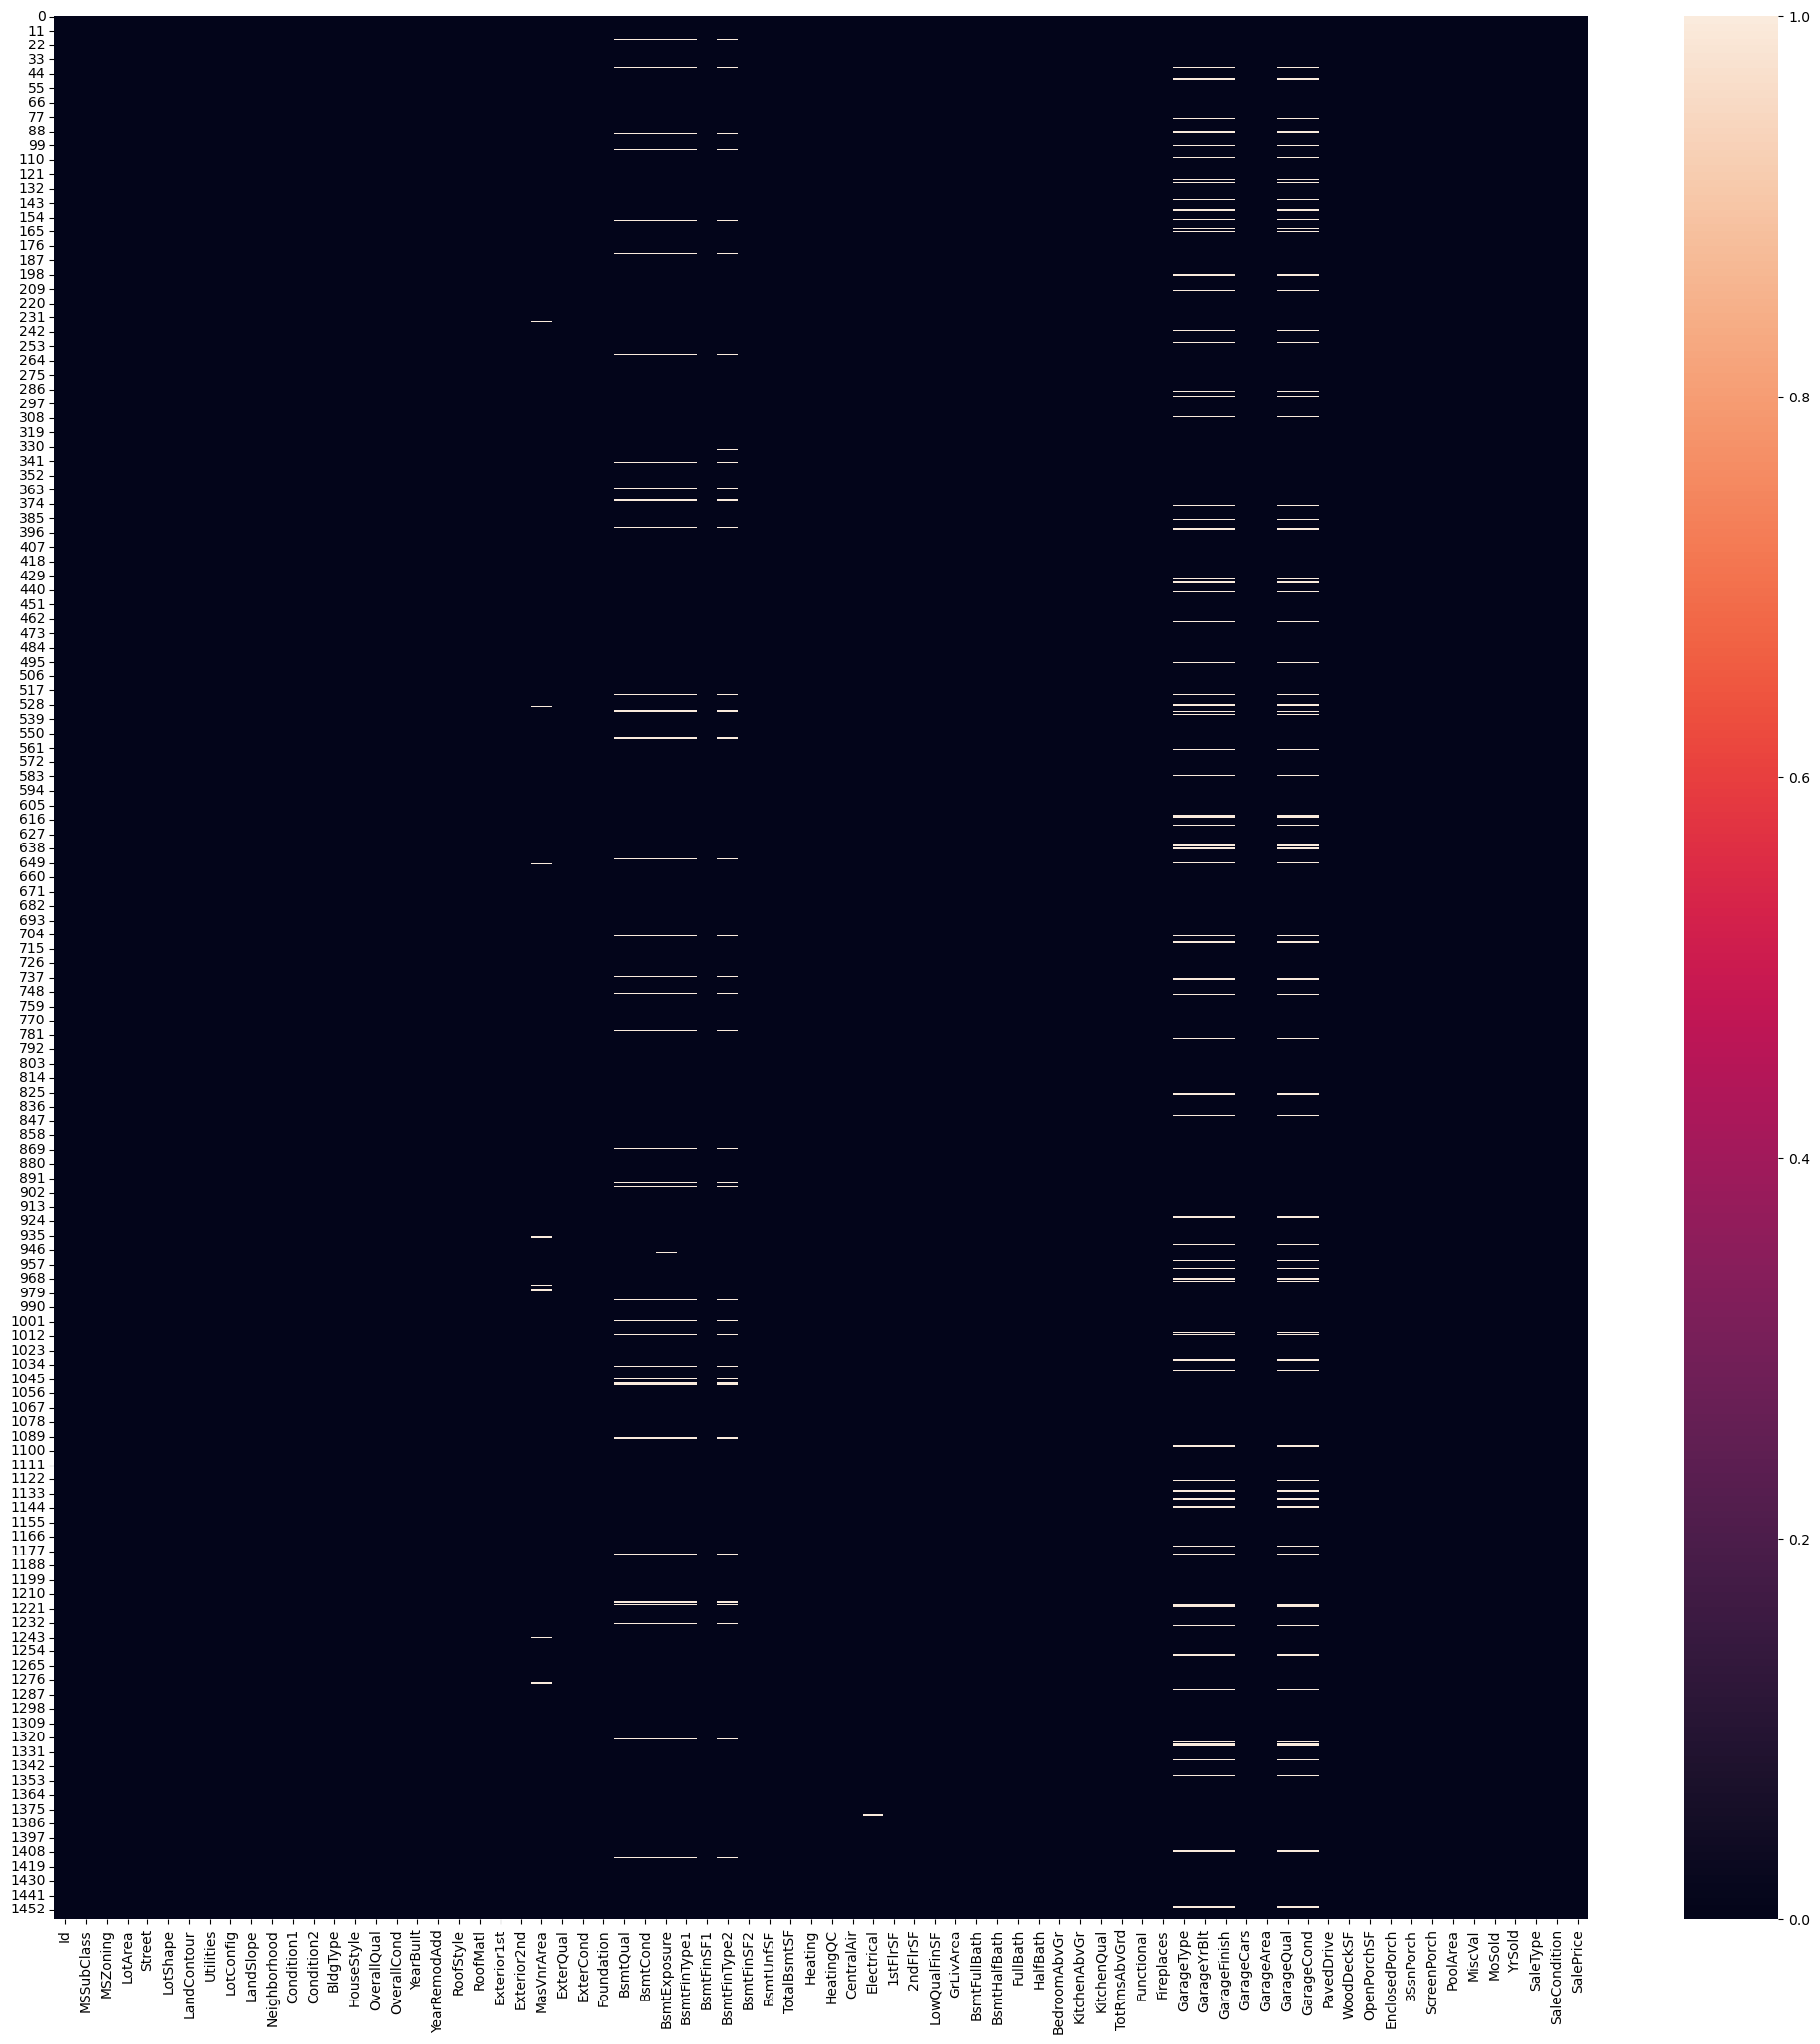

In [ ]:
plt.figure(figsize = (25,25))
sns.heatmap(df2_drop_clm.isnull())

<Axes: >

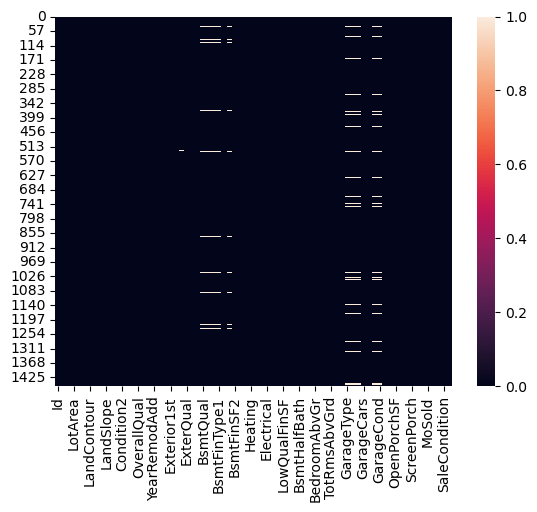

In [ ]:
sns.heatmap(df2_drop_clm.isnull())

In [ ]:
df3_drop_rows = df2_drop_clm.dropna()


In [ ]:
df3_drop_rows.shape

(1338, 74)

<Axes: >

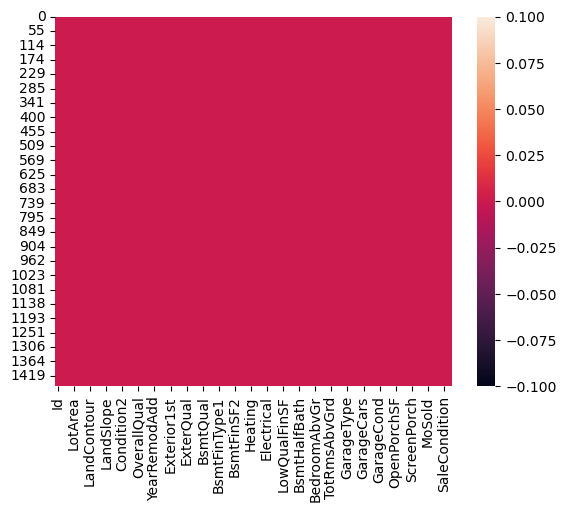

In [ ]:
sns.heatmap(df3_drop_rows.isnull())

In [ ]:
 df3_drop_rows.isna().sum().sum()

np.int64(0)

# Numerical value data Distrubution

In [ ]:
import seaborn as sns

In [ ]:
df3_drop_rows.select_dtypes(include = ['int64','float64']).columns

Index(['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

C:\Users\lenovo\AppData\Local\Temp\ipykernel_14604\498137754.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(h_df['MSSubClass'])


<Axes: xlabel='MSSubClass', ylabel='Density'>

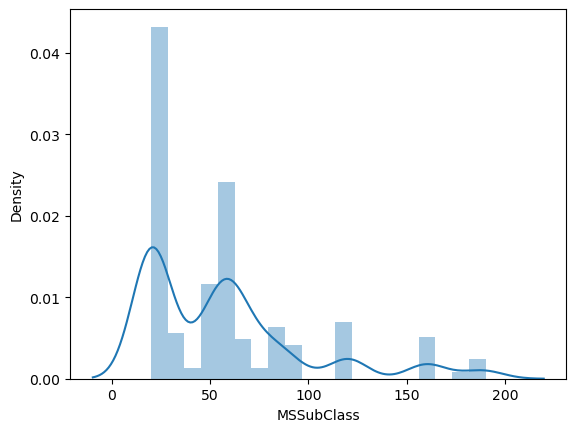

In [ ]:
sns.distplot(h_df['MSSubClass'])

C:\Users\lenovo\AppData\Local\Temp\ipykernel_14604\735329885.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df3_drop_rows['MSSubClass'])


<Axes: xlabel='MSSubClass', ylabel='Density'>

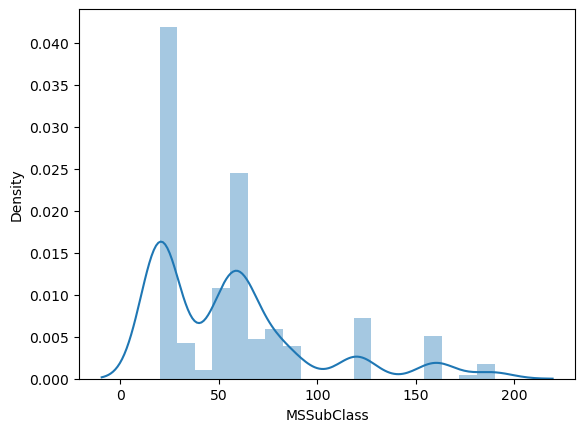

In [ ]:
sns.distplot(df3_drop_rows['MSSubClass'])

C:\Users\lenovo\AppData\Local\Temp\ipykernel_14604\4198052457.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(h_df['MSSubClass'])
C:\Users\lenovo\AppData\Local\Temp\ipykernel_14604\4198052457.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df3_drop_rows['MSSubClass'])


<Axes: xlabel='MSSubClass', ylabel='Density'>

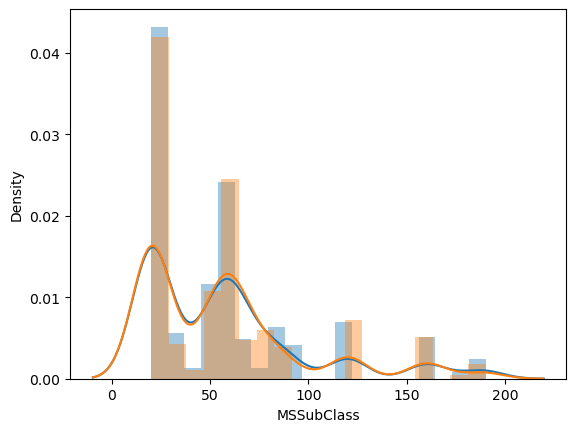

In [ ]:
sns.distplot(h_df['MSSubClass'])
sns.distplot(df3_drop_rows['MSSubClass'])

In [ ]:
numeric_var = ['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice']



C:\Users\lenovo\AppData\Local\Temp\ipykernel_14604\633306944.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(h_df[var], bins = 20)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_14604\633306944.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df3_drop_rows[var], bins = 20)
C:\Users\lenovo\A

ValueError: num must be an integer with 1 <= num <= 36, not 37

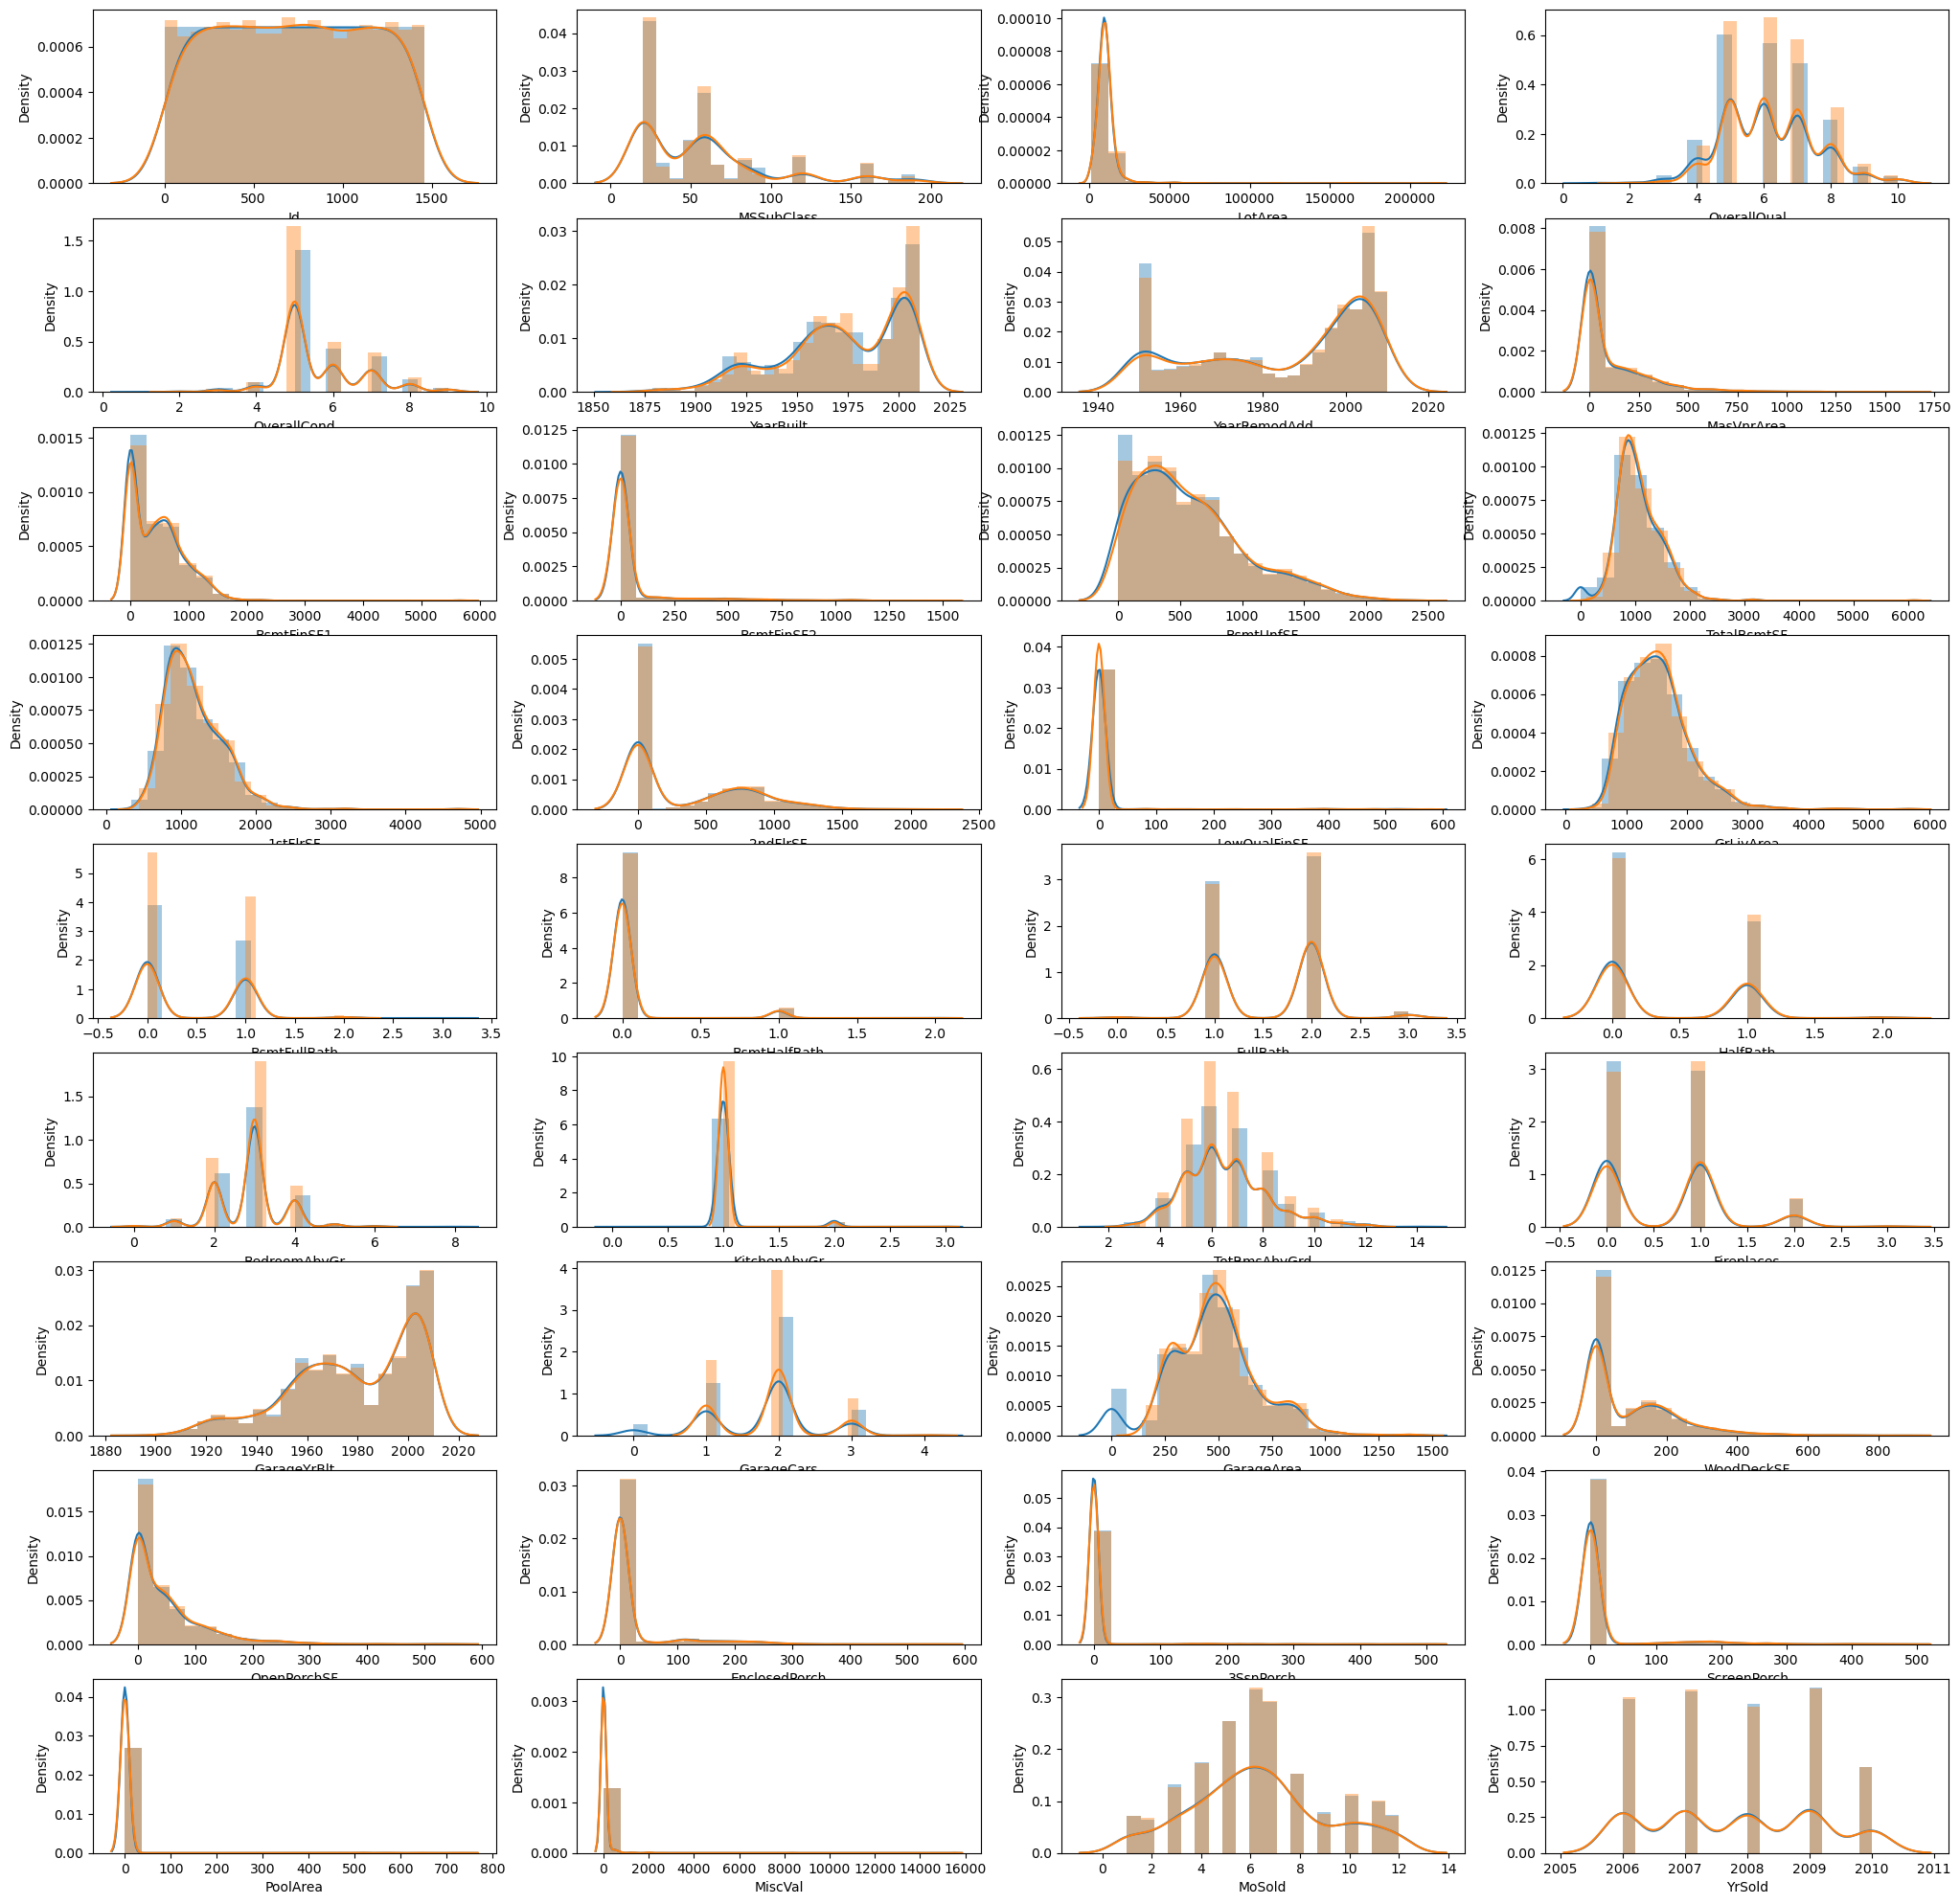

In [ ]:
plt.figure(figsize = (25,25))
for i, var in enumerate(numeric_var):
    plt.subplot(9,4,i+1)
    sns.distplot(h_df[var], bins = 20)
    sns.distplot(df3_drop_rows[var], bins = 20)

# Categorical data Distrubution

In [ ]:
df3_drop_rows.select_dtypes(include = ['object']).columns

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [ ]:
h_df['MSZoning'].value_counts()

MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

In [ ]:
h_df['MSZoning'].value_counts()/df3_drop_rows.shape[0]

MSZoning
RL         0.860239
RM         0.162930
FV         0.048580
RH         0.011958
C (all)    0.007474
Name: count, dtype: float64

In [ ]:
h_df['MSZoning'].value_counts()/df3_drop_rows.shape[0] * 100

MSZoning
RL         86.023916
RM         16.292975
FV          4.857997
RH          1.195815
C (all)     0.747384
Name: count, dtype: float64

In [ ]:
df3_drop_rows['MSZoning'].value_counts()/df3_drop_rows.shape[0] * 100

MSZoning
RL         79.671151
RM         14.275037
FV          4.633782
RH          0.822123
C (all)     0.597907
Name: count, dtype: float64

In [ ]:
pd.concat([h_df['MSZoning'].value_counts()/h_df.shape[0] * 100,
           df3_drop_rows['MSZoning'].value_counts()/df3_drop_rows.shape[0] * 100],
          axis = 1,
          keys = ['MSZoning_Org', 'MSZoning_Clean'])

,MSZoning_Org,MSZoning_Clean
MSZoning,,
RL,78.835616,79.671151
RM,14.931507,14.275037
FV,4.452055,4.633782
RH,1.095890,0.822123
C (all),0.684932,0.597907


In [ ]:
def categarical_var_dist(var):
    return pd.concat([h_df[var].value_counts()/h_df.shape[0] * 100,
           df3_drop_rows[var].value_counts()/df3_drop_rows.shape[0] * 100],
          axis = 1,
          keys = [var+'_Org', var+'_Clean'])

In [ ]:
categarical_var_dist('Street')

,Street_Org,Street_Clean
MSZoning,,
RL,78.835616,79.671151
RM,14.931507,14.275037
FV,4.452055,4.633782
RH,1.095890,0.822123
C (all),0.684932,0.597907


In [ ]:
cat_cols = ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
            'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
            'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
            'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
            'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
            'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
            'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive',
            'SaleType', 'SaleCondition']

for col in cat_cols:
    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print(f"{'='*50}")

    distribution = pd.concat(
        [
            h_df[col].value_counts(normalize=True) * 100,
            df3_drop_rows[col].value_counts(normalize=True) * 100
        ],
        axis=1,
        keys=[f'{col}_Org', f'{col}_Clean']
    )

    print(distribution)


Column: MSZoning
          MSZoning_Org  MSZoning_Clean
MSZoning                              
RL           78.835616       79.671151
RM           14.931507       14.275037
FV            4.452055        4.633782
RH            1.095890        0.822123
C (all)       0.684932        0.597907

Column: Street
        Street_Org  Street_Clean
Street                          
Pave     99.589041     99.626308
Grvl      0.410959      0.373692

Column: LotShape
          LotShape_Org  LotShape_Clean
LotShape                              
Reg          63.356164       61.958146
IR1          33.150685       34.304933
IR2           2.808219        2.989537
IR3           0.684932        0.747384

Column: LandContour
             LandContour_Org  LandContour_Clean
LandContour                                    
Lvl                89.794521          90.134529
Bnk                 4.315068           3.886398
HLS                 3.424658           3.587444
Low                 2.465753           2.391629
